In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random


from sklearn.preprocessing import LabelEncoder
from imutils import paths
from PIL import Image,UnidentifiedImageError
from numpy import asarray
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline


In [8]:
def synthetic_data(image):
    img = Image.fromarray(image)

    oprations = ['flip','rotate','brightness','crop']
    op  = random.choice(oprations)

    if op=="flip":
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
    elif op=="rotate":
        angle=random.uniform(-10,10)
        img = img.rotate(angle)
    elif op =="brightness":
        factor = random.uniform(0.85,1.15)
        img=Image.fromarray(np.clip(np.array(img)*factor,0,255).astype(np.uint8))
    elif op=="crop":
        w,h = img.size
        crop_w=int(w*0.1)
        crop_h=int(h*0.1)

        img=img.crop((crop_w,crop_h,w-crop_w,h-crop_h))
        img=img.resize((w,h))
    return np.array(img)

In [9]:
def chunk_image(image, chunks=4, overlap=0.2):
    h, w = image.shape[:2]
    pieces = []
    window_size = 32
    step_size = 16
    for y in range(0, h - window_size + 1, step_size):
        for x in range(0, w - window_size + 1, step_size):
            chunk = image[y:y + window_size, x:x + window_size]
            pieces.append(chunk)

    if h % step_size != 0:
        for x in range(0, w - window_size + 1, step_size):
            chunk = image[h - window_size:h, x:x + window_size]
            pieces.append(chunk)
    if w % step_size != 0:
        for y in range(0, h - window_size + 1, step_size):
            chunk = image[y:y + window_size, w - window_size:w]
            pieces.append(chunk)
    if h % step_size != 0 and w % step_size != 0:
        chunk = image[h - window_size:h, w - window_size:w]
        pieces.append(chunk)

    return pieces


In [10]:
def lbp_numpy(gray):
    h,w = gray.shape
    lbp_image = np.zeros((h,w),dtype=np.uint8)
    neighbors = [
        (-1,-1),(-1,0),(-1,1),
        (0,1),
        (1,1),(1,0),(1,-1),
        (0,-1)
    ]
    for y in range(1,h-1):
        for x in range(1,w-1):
            center = gray[y,x]
            binary_string = ''
            for dy,dx in neighbors:
                neighbor = gray[y+dy,x+dx]
                binary_string += '1' if neighbor > center else '0'
            lbp_image [y,x] = int(binary_string,2)
    hist,_ = np.histogram(lbp_image.ravel(),bins=256,range=(0,256))
    hist = hist.astype("float") / (hist.sum()+ 1e-6)
    return hist

In [11]:
def hog_numpy(gray,cell_size=16,block_size=2,bins=9):
    h, w = gray.shape
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=1)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=1)
    magnitude = np.sqrt(gx**2 + gy**2)
    angle = (np.arctan2(gy, gx) * 180 / np.pi) % 180
    cell_x = w // cell_size
    cell_y = h // cell_size
    hist = np.zeros((cell_y, cell_x, bins))
    bin_width = 180 / bins
    for i in range(cell_y):
        for j in range(cell_x):
            mag_block = magnitude[i*cell_size:(i+1)*cell_size, j*cell_size:(j+1)*cell_size]
            ang_block = angle[i*cell_size:(i+1)*cell_size, j*cell_size:(j+1)*cell_size]
            for y in range(cell_size):
                for x in range(cell_size):
                    mag = mag_block[y,x]
                    ang = ang_block[y,x]
                    bin_idx = int(ang // bin_width)
                    hist[i,j,bin_idx] += mag
    hog_features = []
    for i in range(cell_y - block_size + 1):
        for j in range(cell_x - block_size + 1):
            block = hist[i:i+block_size, j:j+block_size].ravel()
            norm = np.linalg.norm(block) + 1e-6
            hog_features.append(block / norm)
    hog_features = np.concatenate(hog_features)
    return hog_features
    
def Open_and_resize(image_path):
    image = Image.open(image_path).convert("RGB")
    resize_image = image.resize((128,128))
    data = asarray(resize_image)
    return data
    
def good_image(arr):
    gray = np.dot(arr[...,:3], [0.299, 0.587, 0.114]).astype(np.uint8)

    blur = cv2.Laplacian(gray, cv2.CV_64F).var()
    brightness = np.mean(gray)

    if blur < 5:
        return False
    if brightness < 10 or brightness > 245:
        return False

    return True



In [12]:
X = []
Y = []
def process_image(arr,label):
    if arr.shape == (128,128,3) and good_image(arr):
        gray = np.dot(arr[...,:3], [0.299, 0.587, 0.114]).astype(np.uint8)
        chunks = chunk_image(gray)

        lbp_feats = []
        hog_feats = []

        for ch in chunks:
            lbp_feats.append(lbp_numpy(ch))
            hog_feats.append(hog_numpy(ch))

        lbp_feat = np.concatenate(lbp_feats)
        hog_feat = np.concatenate(hog_feats)

        features = np.concatenate([lbp_feat, hog_feat])

        X.append(features)
        Y.append(label)

    return X, Y


In [13]:
dataset = r'C:\Users\Ghazal\Documents\GitHub\Cats_and_dogs-CNN\PetImages'
image_list = os.listdir(dataset)
AUG_PER_IMAGE = 2


for folder in image_list:
    folder_path = os.path.join(dataset, folder)

    if "Cat" in folder:
        label = "Cat"
    elif "Dog" in folder:
        label = "Dog"
    else:
        continue
    for img_name in tqdm(os.listdir(folder_path)):
        img_path = os.path.join(folder_path, img_name)
        try:
            arr = Open_and_resize(img_path)
            if arr.shape == (128,128,3) and good_image(arr):
                X,Y = process_image(arr,label)
                for _ in range(AUG_PER_IMAGE):
                    aug = synthetic_data(arr)
                    X,Y = process_image(aug,label)
        except (UnidentifiedImageError, OSError):
            print("Can't open:", img_path)

X = np.array(X)
Y = np.array(Y)

 91%|███████████████████████████████████████████████████████████████████▋      | 11436/12499 [1:03:05<05:48,  3.05it/s]C:\Users\Ghazal\Documents\GitHub\Cats_and_dogs-CNN\venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████████████████████████████████████████████████████████████████████| 12499/12499 [1:08:56<00:00,  3.02it/s]


In [37]:
good_bad_stats = {"Cat": [0, 0], "Dog": [0, 0]}

for folder in image_list:
    folder_path = os.path.join(dataset, folder)

    if "Cat" in folder:
        label = "Cat"
    elif "Dog" in folder:
        label = "Dog"
    else:
        continue

    for img_name in tqdm(os.listdir(folder_path)):
        img_path = os.path.join(folder_path, img_name)
        try:
            arr = Open_and_resize(img_path)
            if arr.shape != (128,128,3):
                continue

            ok = good_image(arr)
            if ok:
                good_bad_stats[label][0] += 1 
            else:
                good_bad_stats[label][1] += 1   

        except:
            pass

for cls in good_bad_stats:
    good, bad = good_bad_stats[cls]
    print(cls, "Good:", good, ", Bad:", bad, ", Removed %:", bad/(good+bad)*100)


100%|███████████████████████████████████████████████████████████████████████████| 12499/12499 [00:37<00:00, 336.21it/s]

Cat Good: 12496 , Bad: 3 , Removed %: 0.02400192015361229
Dog Good: 12498 , Bad: 1 , Removed %: 0.008000640051204096


In [14]:
lable = LabelEncoder()
y_lable = lable.fit_transform(Y)

x_train,x_test,y_train,y_test=train_test_split(X,y_lable,test_size=0.1,random_state=42,stratify=y_lable)

In [15]:
pipe = Pipeline([
    ('scaler',StandardScaler()),
    ('pca', PCA(n_components=300)),
    ('svm',SVC(kernel="rbf", C=100, gamma='scale', degree=3,class_weight="balanced"))
])


In [16]:
pipe.fit(x_train,y_train)

y_predict = pipe.predict(x_test)

print("Confusion matrix results:\n",confusion_matrix(y_test,y_predict))
print("\nClassification report of model:\n",classification_report(y_test,y_predict))
print("Accuracy score:",100*accuracy_score(y_test,y_predict))

Confusion matrix results:
 [[3584  165]
 [ 130 3620]]

Classification report of model:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96      3749
           1       0.96      0.97      0.96      3750

    accuracy                           0.96      7499
   macro avg       0.96      0.96      0.96      7499
weighted avg       0.96      0.96      0.96      7499

Accuracy score: 96.06614215228697


In [20]:
import pickle

with open("svm_model.pkl", "wb") as f:
    pickle.dump({
        "pipeline": pipe,
        "label_encoder": lable
    }, f, protocol=pickle.HIGHEST_PROTOCOL)

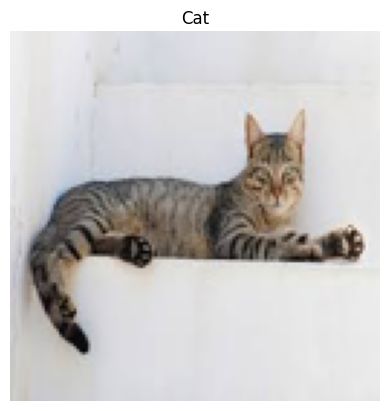

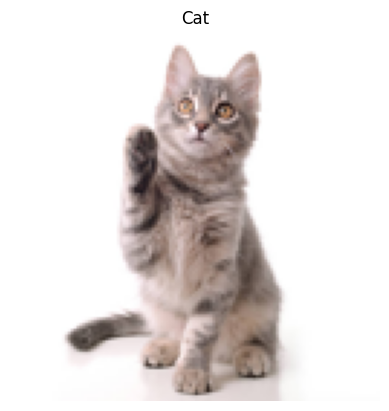

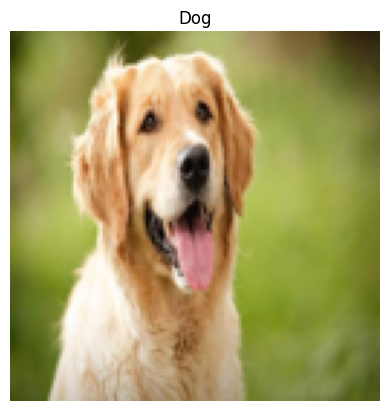

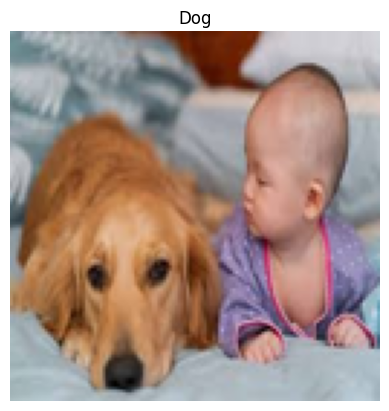

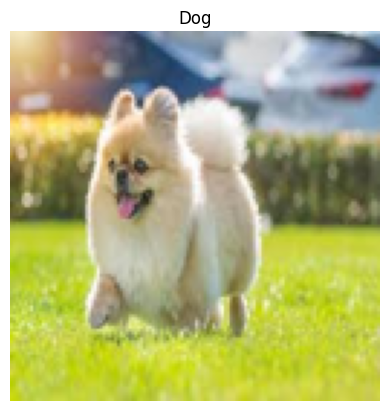

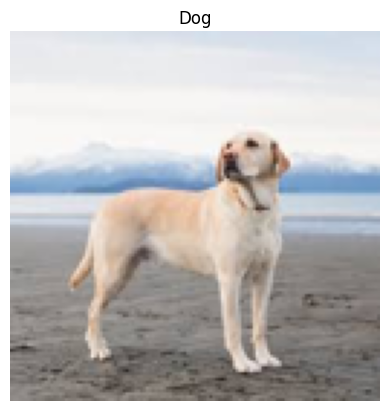

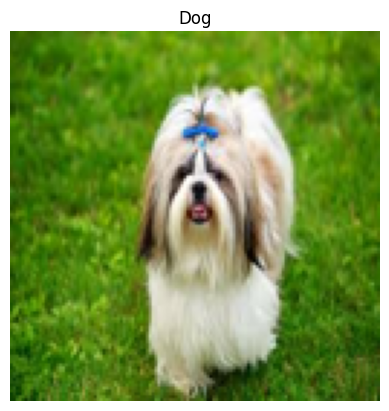

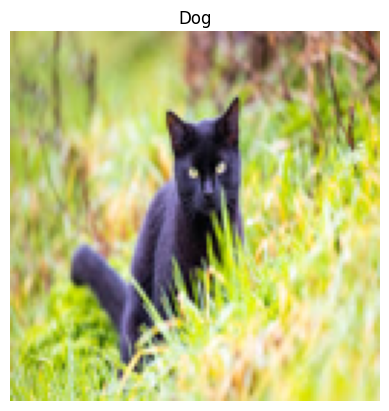

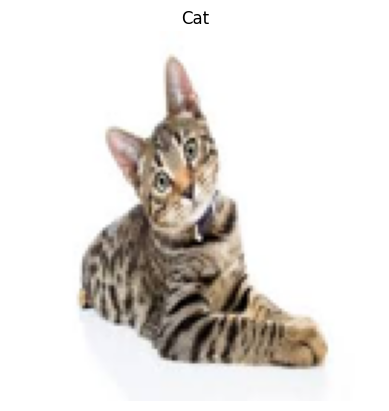

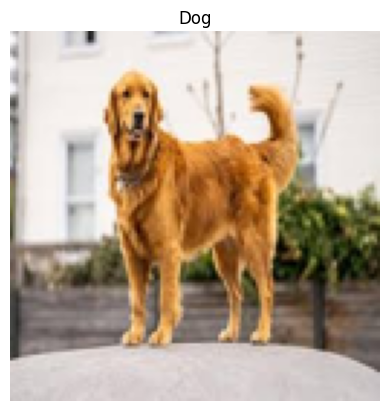

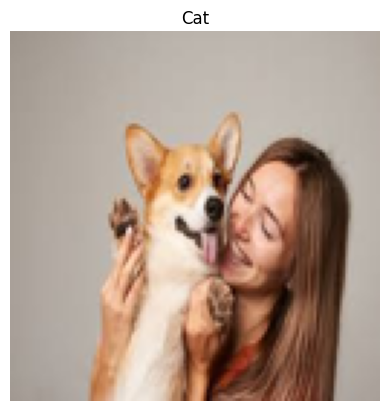

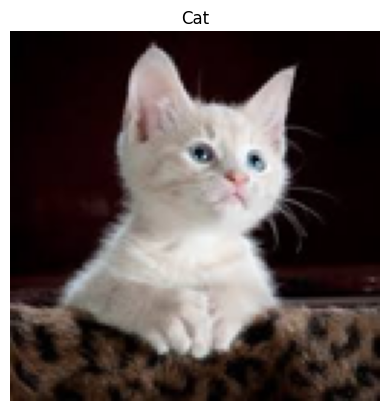

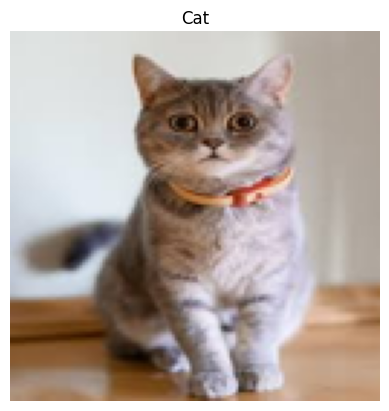

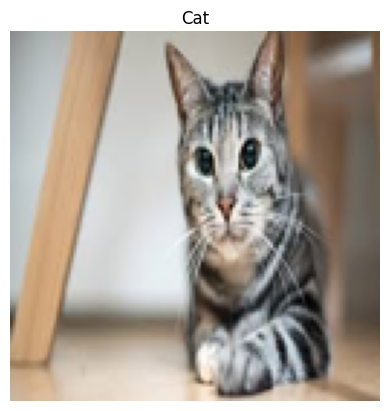

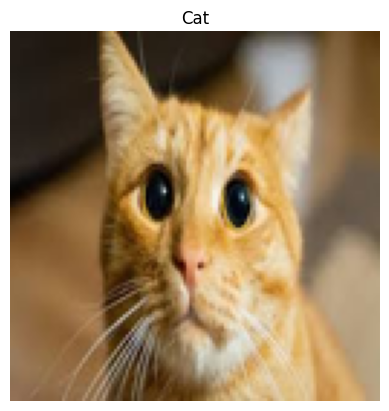

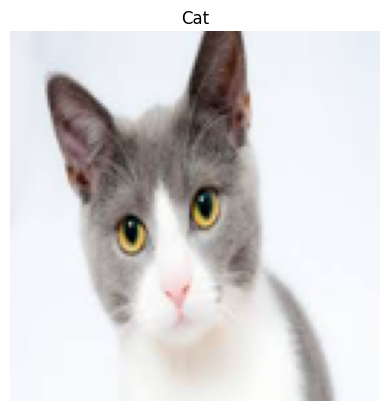

In [25]:
def predict_image(folder_path, pipeline, label_encoder):
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path,img_name)
        try:
            arr = Open_and_resize(img_path) 
            if arr.shape != (128,128,3) or not good_image(arr):
                continue
            gray = np.dot(arr[...,:3], [0.299,0.587,0.114]).astype(np.uint8)
            chunks = chunk_image(gray)
            lbp_feats = []
            hog_feats = []
            for ch in chunks:
                lbp_feats.append(lbp_numpy(ch))
                hog_feats.append(hog_numpy(ch))
            lbp_feat = np.concatenate(lbp_feats)
            hog_feat = np.concatenate(hog_feats)
            features = np.concatenate([lbp_feat, hog_feat]).reshape(1, -1)
            
            pred = pipeline.predict(features)[0]
            pred_label = label_encoder.inverse_transform([pred])[0]

            plt.imshow(arr)
            plt.title(pred_label)
            plt.axis('off')
            plt.show()
        except Exception as e:
            print("Can't open:", img_path, "| Error:", e)


# Load مدل و pipeline pickle شده
with open("svm_model.pkl", "rb") as f:
    data = pickle.load(f)

pipeline = data["pipeline"]
label_encoder = data["label_encoder"]
dataset = r"C:\Users\Ghazal\Desktop\test"
predict_image(dataset, pipe, lable)
